In [11]:
import re
import os
import glob
import numpy as np
import xarray as xr
from scipy import stats
import cartopy.crs as ccrs
from xesmf import Regridder
import matplotlib.pyplot as plt
from matplotlib.path import Path
from collections import defaultdict
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
from cartopy.util import add_cyclic_point


# ---- Functions ----
def spatial_average(array, lats, num_lons):
    weights = np.cos(np.deg2rad(lats))
    if len(array.shape) == 2:
        weights_array = weights[:, np.newaxis]
        weighted_array = np.multiply(array, weights_array)
        shape = np.shape(weighted_array)
        weighted_reshaped = np.reshape(weighted_array, (shape[0]*shape[1]))
        weighted_sum = np.nansum(weighted_reshaped, axis=0)
    if len(array.shape) == 3:
        weights_array = weights[np.newaxis, :, np.newaxis]
        weighted_array = np.multiply(array, weights_array)
        shape = np.shape(weighted_array)
        weighted_reshaped = np.reshape(weighted_array, (shape[0], shape[1]*shape[2]))
        weighted_sum = np.nansum(weighted_reshaped, axis=1)
    if len(array.shape) == 4:
        weights_array = weights[np.newaxis, np.newaxis, :, np.newaxis]
        weighted_array = np.multiply(array, weights_array)
        shape = np.shape(weighted_array)
        weighted_reshaped = np.reshape(weighted_array, (shape[0], shape[1], shape[2]*shape[3]))
        weighted_sum = np.nansum(weighted_reshaped, axis=2)
    if len(array.shape) == 5:
        weights_array = weights[np.newaxis, np.newaxis, np.newaxis, :, np.newaxis]
        weighted_array = np.multiply(array, weights_array)
        shape = np.shape(weighted_array)
        weighted_reshaped = np.reshape(weighted_array, (shape[0], shape[1], shape[2], shape[3]*shape[4]))
        weighted_sum = np.nansum(weighted_reshaped, axis=3)
    denom = np.nansum(weights) * num_lons
    return np.divide(weighted_sum, denom)


def plot_region(ax, lon_min, lon_max, lat_min, lat_max, n_points=100, **kwargs):
    lons = np.concatenate([
        np.linspace(lon_min, lon_max, n_points),
        lon_max*np.ones(n_points),
        np.linspace(lon_max, lon_min, n_points),
        lon_min*np.ones(n_points)
    ])
    lats = np.concatenate([
        lat_min*np.ones(n_points),
        np.linspace(lat_min, lat_max, n_points),
        lat_max*np.ones(n_points),
        np.linspace(lat_max, lat_min, n_points)
    ])
    ax.plot(lons, lats, transform=ccrs.PlateCarree(), **kwargs)


# ---- Settings ----
# Circular boundary for clipping
theta = np.linspace(0, 2 * np.pi, 100)
center = (0.5, 0.5)
radius = 0.5  # in axes coords
verts = np.vstack([np.sin(theta), np.cos(theta)]).T * radius + center
circle_path = Path(verts)

### Load data

In [3]:
# ---- Observations ----
# Surface air temperature (K)
sat_paths = glob.glob('../data/obs-trends/SAT/*')

sat_data = []
for path in sat_paths:
    ds = xr.open_dataset(path).DATA
    sat_data.append(ds)
obs_sat = np.nanmean(sat_data, axis=0)[2:5]

# Sea level pressure (hPa)
slp_paths = glob.glob('../data/obs-trends/SLP/*')

slp_data = []
for path in slp_paths:
    ds = xr.open_dataset(path).DATA
    slp_data.append(ds)
obs_slp = np.nanmean(slp_data, axis=0)[2:5] / 100  # convert to hPa

# lat, lon
lat, lon = ds.lat.values, ds.lon.values

# Check shapes
print('obs_sat:', np.shape(obs_sat))
print('obs_slp:', np.shape(obs_slp))

obs_sat: (3, 72, 144)
obs_slp: (3, 72, 144)


In [136]:
# ----- Simulated Data -----
sim_paths = glob.glob('../data/sim-trends/*')

sim_sat, sim_slp = [], []
for path in sim_paths:

    # Select MAM, 1980-2022, scaled for forcing bias
    ds = xr.open_dataset(path).X_SAT_SLP.isel(period=-6).sel(month=slice(2, 4))[:, :, :, :, 0] * (0.213/0.260)
    ds_ = xr.open_dataset(path).X_SAT_SLP.isel(period=-6).sel(month=slice(2, 4))[:, :, :, :, 1]

    # Append ensemble mean
    sim_sat.append(np.nanmean(ds, axis=0))
    sim_slp.append(np.nanmean(ds_, axis=0))

# MMM
mod_sat = np.nanmean(sim_sat, axis=0)
mod_slp = np.nanmean(sim_slp, axis=0)

# Check shapes
print('mod_sat:', np.shape(mod_sat))
print('mod_slp:', np.shape(mod_slp))

mod_sat: (3, 72, 144)
mod_slp: (3, 72, 144)


In [10]:
# ----- Internal Trend Maps -----
df_internal = np.load("../data/df_internal.npz", allow_pickle=False)
sat_internal = df_internal["SAT_internal"]
slp_internal = df_internal["SLP_internal"]

# Check shape
print('sat_internal:', np.shape(sat_internal))
print('slp_internal:', np.shape(slp_internal))

sat_internal: (8966, 3, 72, 144)
slp_internal: (8966, 3, 72, 144)


In [44]:
# ---- Wind-Nudged Data ----
nudged_paths = sorted(glob.glob('../data/PInudge/*'))

# Group files by variable name
file_dict = defaultdict(list)
for path in nudged_paths:
    fname = os.path.basename(path)
    var_match = re.search(r'(PSL|TREFHT)', fname)
    if var_match:
        varname = var_match.group(1)
        file_dict[varname].append(path)

# Put all processed data together
arrays = []
for varname, files in file_dict.items():
    print(f"Processing {varname} from {len(files)} file(s)...")

    # Each file is a different ensemble member
    datasets = []
    for path in files:
        ens_match = re.search(r'\.(\d{3})\.h0', os.path.basename(path))
        ens = ens_match.group(1) if ens_match else '000'
        ds = xr.open_dataset(path, chunks={'time': 12})
        ds = ds.assign_coords(ensemble=int(ens))
        datasets.append(ds)

    # Combine along a new ensemble dimension
    ds = xr.concat(datasets, dim='ensemble')

    # Select March–May, 1980–2022
    ds = ds.sel(time=slice("1980-01-01", "2022-12-31"))
    ds = ds.sel(time=ds['time'].dt.month.isin([4, 5, 6]))

    # Append to list
    arrays.append(ds[varname])

# Combine all variables
ds = xr.concat(arrays, dim='variable')

# Create year and month coordinates
years = np.unique(ds['time'].dt.year)
months = np.unique(ds['time'].dt.month)
nudged_lat = ds.lat.values
nudged_lon = ds.lon.values

# Group by year and month
df = ds.groupby('time.year').apply(
    lambda ds_year: ds_year.groupby('time.month').mean('time')
)

# Assign year and month coordinates
df = df.assign_coords(
    year=years,
    month=months
).transpose('ensemble', 'variable', 'year', 'month', 'lat', 'lon')
df.name = 'nudged_variables'

# Compute the linear trend for each variable, month, lat, and lon per decade
nudged_trends = df.polyfit(dim='year', deg=1)['polyfit_coefficients'].sel(degree=1) * 10

# Get separate numpy arrays
nudged_slp_ens = nudged_trends[:, 0].values / 100  # hPa
nudged_sat_ens = nudged_trends[:, 1].values

# Array with separate ensemble members (native grid)
# (ens, months, lat, lon)
print('\nnudged_sat_ens:', np.shape(nudged_sat_ens))

# Array with ensemble mean (native grid)
nudged_sat = np.mean(nudged_sat_ens, axis=0)
nudged_slp = np.mean(nudged_slp_ens, axis=0)
print('nudged_sat:    ', np.shape(nudged_sat))

# Array with ensemble mean (regridded to 2.5 x 2.5 deg)
regridder = Regridder(ds, xr.Dataset({'lat': (['lat'], lat), 'lon': (['lon'], lon)}), 'bilinear', reuse_weights=False) 
nudged_sat_rg = regridder(nudged_sat)
nudged_slp_rg = regridder(nudged_slp)
print('nudged_sat_rg: ', np.shape(nudged_sat_rg))

Processing PSL from 3 file(s)...
Processing TREFHT from 3 file(s)...

nudged_sat_ens: (3, 3, 192, 288)
nudged_sat:     (3, 192, 288)
nudged_sat_rg:  (3, 72, 144)


### Figure 1 - Monthly trend maps

In [5]:
print(f"Min March SLP: {np.nanmin(obs_slp[0])*100:.0f} Pa/decade")
print(f"Max April SAT: {np.nanmax(obs_sat[1]):.1f} K/decade")

Min March SLP: -312 Pa/decade
Max April SAT: 1.7 K/decade


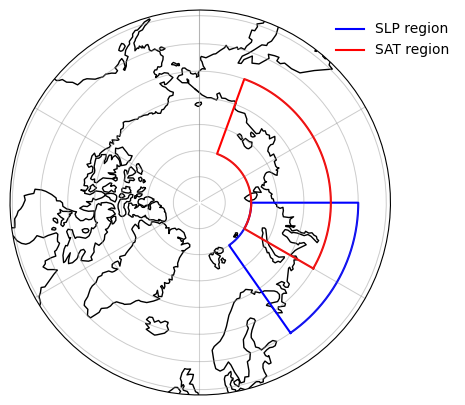

In [17]:
# Define region bounds (lon_min, lon_max, lat_min, lat_max)
regions = [(35, 90, 60, 80), (60, 160, 65, 80)]

fig = plt.figure(figsize=(5, 5))
ax = plt.subplot(1, 1, 1, projection=ccrs.NorthPolarStereo())
ax.set_extent([-180, 180, 54, 90], crs=ccrs.PlateCarree())

ax.coastlines(resolution='110m')
ax.set_boundary(circle_path, transform=ax.transAxes)
ax.gridlines(alpha=0.3)

# Highlight regions
colors = ['blue', 'red']
labels = ['SLP region', 'SAT region']
for i, (lon_min, lon_max, lat_min, lat_max) in enumerate(regions):
    plot_region(ax, lon_min, lon_max, lat_min, lat_max, color=colors[i], linewidth=1.5, label=labels[i])

gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=False,
    linewidth=0.5,
    color='gray',
    alpha=0.3,
)

plt.legend(loc='upper left', bbox_to_anchor=(0.825, 1.), frameon=False)
plt.show()

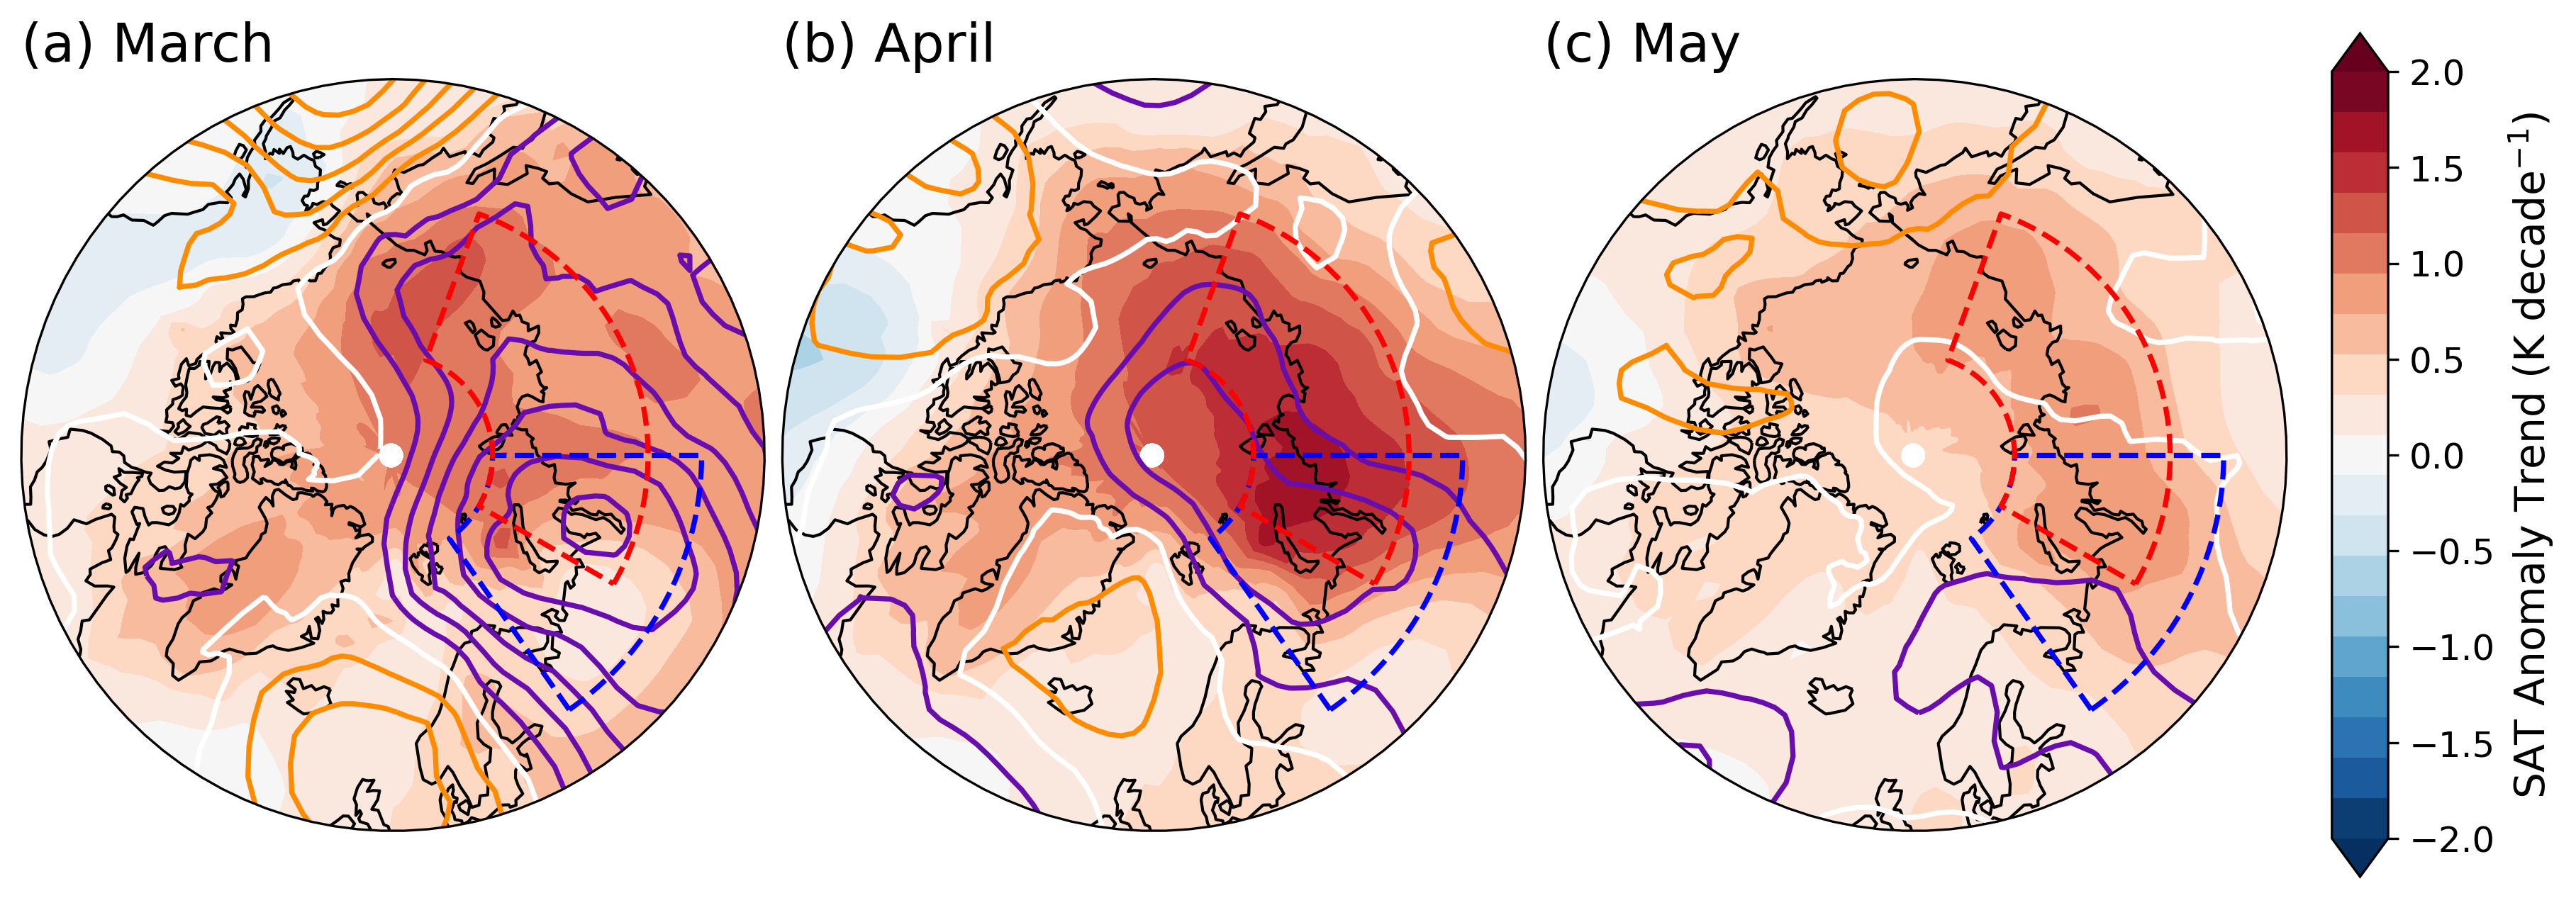

In [26]:
# 1x3 subplots with shared colorbar
fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 10),
    subplot_kw={'projection': ccrs.NorthPolarStereo()},
    dpi=300,
    constrained_layout=True
)

labels = ["(a) March", "(b) April", "(c) May"]
regions = [(35, 90, 60, 80), (60, 160, 65, 80)]

# Loop through each subplot
for i, ax in enumerate(axes):

    ax.coastlines(resolution='110m')
    ax.set_title(labels[i], fontsize=18, loc='left')
    ax.set_boundary(circle_path, transform=ax.transAxes)
    ax.set_extent([-180, 180, 54, 90], crs=ccrs.PlateCarree())

    # Filled SAT contours
    sat_map_cyclic, lon_cyclic = add_cyclic_point(obs_sat[i], coord=lon)
    im = ax.contourf(
        lon_cyclic, lat, sat_map_cyclic,
        cmap="RdBu_r",
        levels=np.linspace(-2, 2, 20),
        extend='both',
        transform=ccrs.PlateCarree()
    )

    # Contour lines of SLP
    slp_map_cyclic, lon_cyclic = add_cyclic_point(obs_slp[i], coord=lon)
    levels = np.linspace(-4, 4, 17)
    colors = []
    for lev in levels[:-1]:
        if lev < 0:
            colors.append('#6a0dad')
        else:
            colors.append('#ff8c00')

    # White zero line
    zero_index = np.where(levels == 0)[0]
    if zero_index.size > 0:
        colors[zero_index[0]] = '#ffffff'
    ax.contour(
        lon_cyclic, lat, slp_map_cyclic,
        colors=colors,
        levels=levels,
        linewidths=1.75,
        transform=ccrs.PlateCarree()
    )

    # Highlight regions
    colors = ['blue', 'red']
    for i, (lon_min, lon_max, lat_min, lat_max) in enumerate(regions):
        plot_region(ax, lon_min, lon_max, lat_min, lat_max, color=colors[i], linewidth=1.75, linestyle='--')

# Shared horizontal colorbar at bottom
cbar = fig.colorbar(
    im,
    ax=axes.ravel(),
    orientation='vertical',
    ticks=np.linspace(-2, 2, 9),
    shrink=0.4,
    aspect=15,
    pad=0.02
)

cbar.ax.tick_params(labelsize=12)
cbar.set_label("SAT Anomaly Trend (K decade$^{-1}$)", fontsize=14)
plt.savefig('../figures/Figure1.png', dpi=300, bbox_inches='tight')
plt.show()

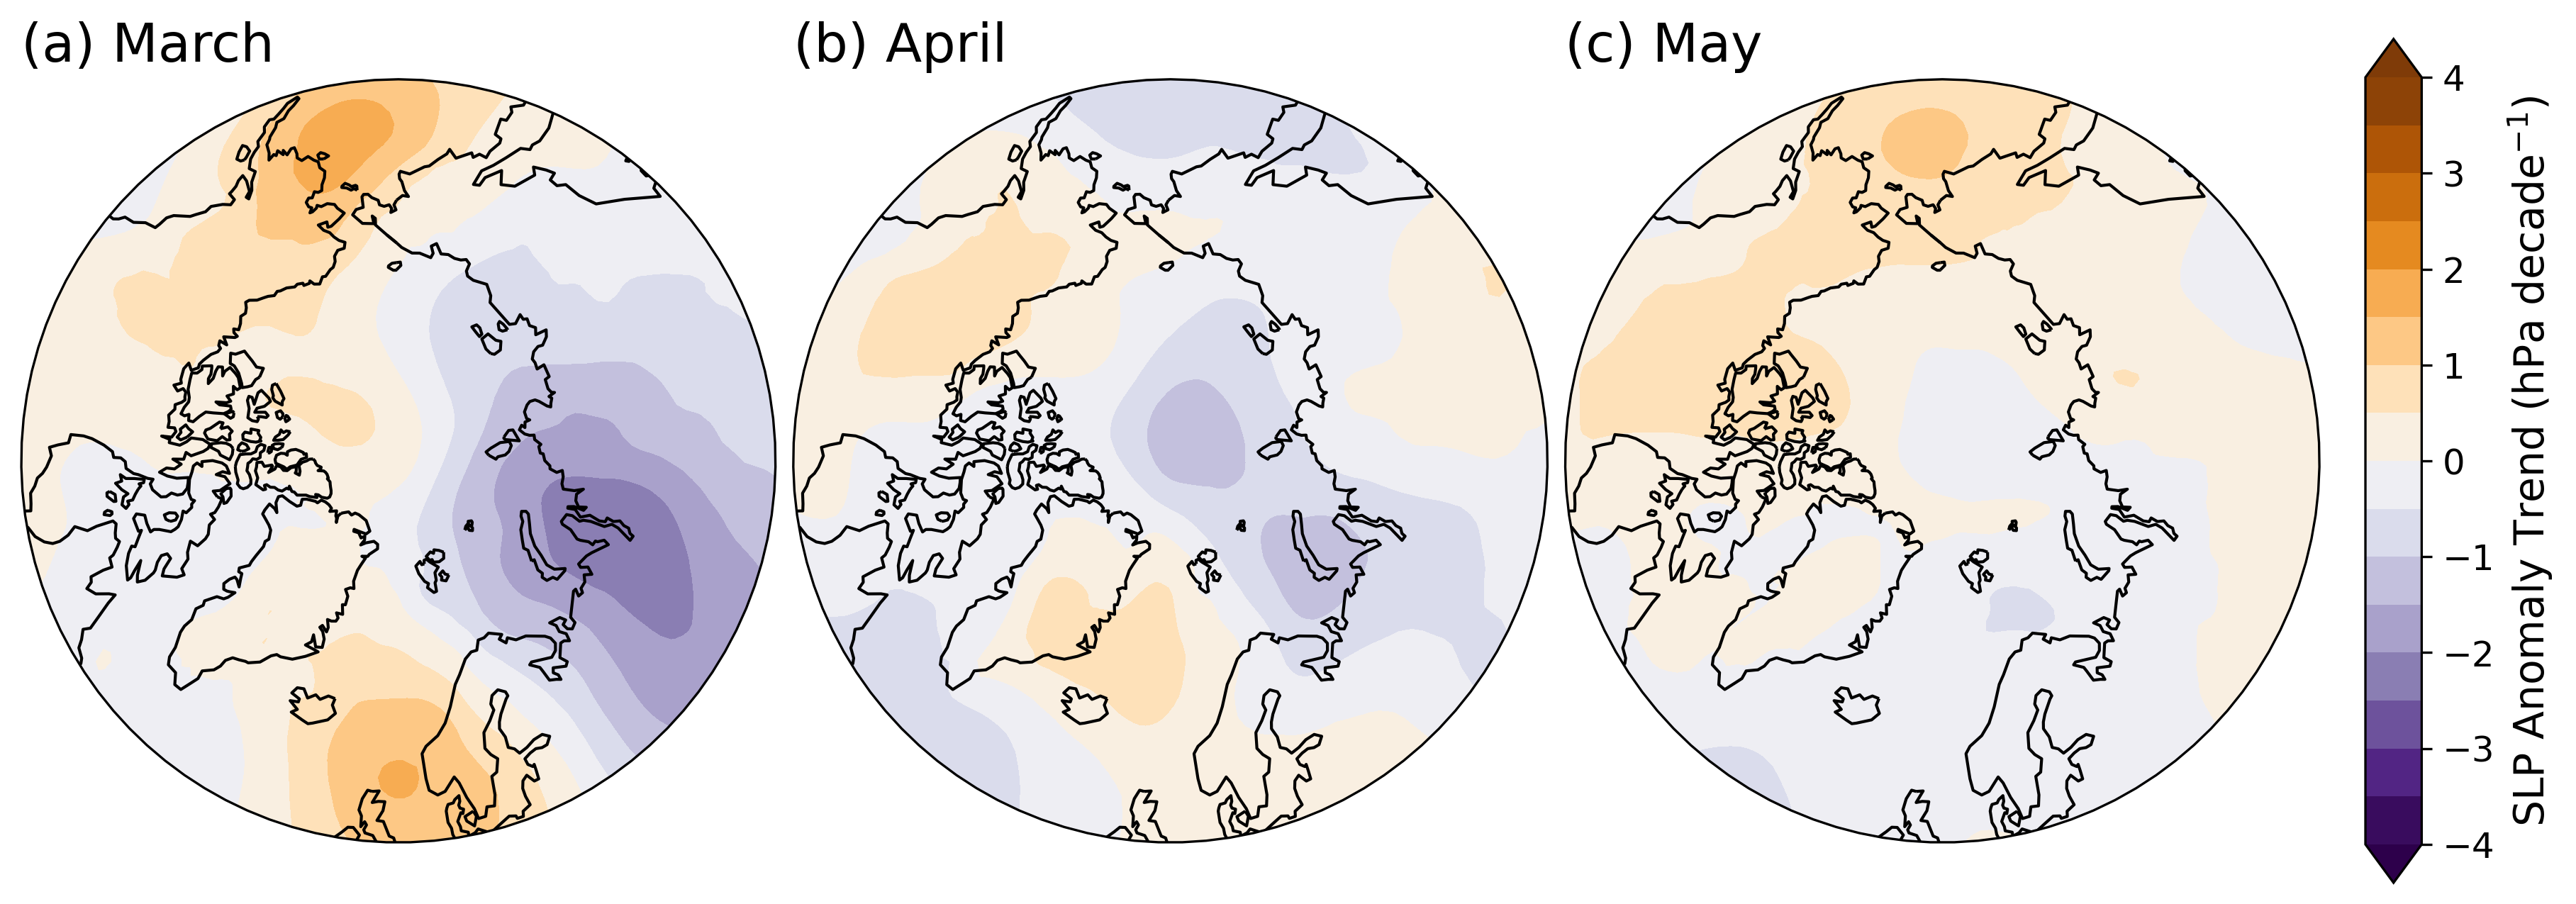

In [27]:
# 1x3 subplots with shared colorbar
fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 10),
    subplot_kw={'projection': ccrs.NorthPolarStereo()},
    dpi=300,
    constrained_layout=True
)

labels = ["(a) March", "(b) April", "(c) May"]

# Loop through each subplot
for i, ax in enumerate(axes):
    ax.set_extent([-180, 180, 54, 90], crs=ccrs.PlateCarree())

    slp_map_cyclic, lon_cyclic = add_cyclic_point(nudged_slp[i], coord=nudged_trends.lon.values)

    im = ax.contourf(
        lon_cyclic,
        nudged_trends.lat.values,
        slp_map_cyclic,
        cmap='PuOr_r',
        levels=np.linspace(-4, 4, 17),
        extend='both',
        transform=ccrs.PlateCarree()
    )

    ax.coastlines(resolution='110m')
    ax.set_title(labels[i], fontsize=18, loc='left')
    ax.set_boundary(circle_path, transform=ax.transAxes)

# Shared horizontal colorbar at bottom
cbar = fig.colorbar(
    im,
    ax=axes.ravel(),
    orientation='vertical',
    ticks=np.linspace(-4, 4, 9),
    shrink=0.4,
    aspect=15,
    pad=0.02
)

cbar.ax.tick_params(labelsize=12)
cbar.set_label("SLP Anomaly Trend (hPa decade$^{-1}$)", fontsize=14)
plt.show()

### Figure 2 - Trend breakdown panels

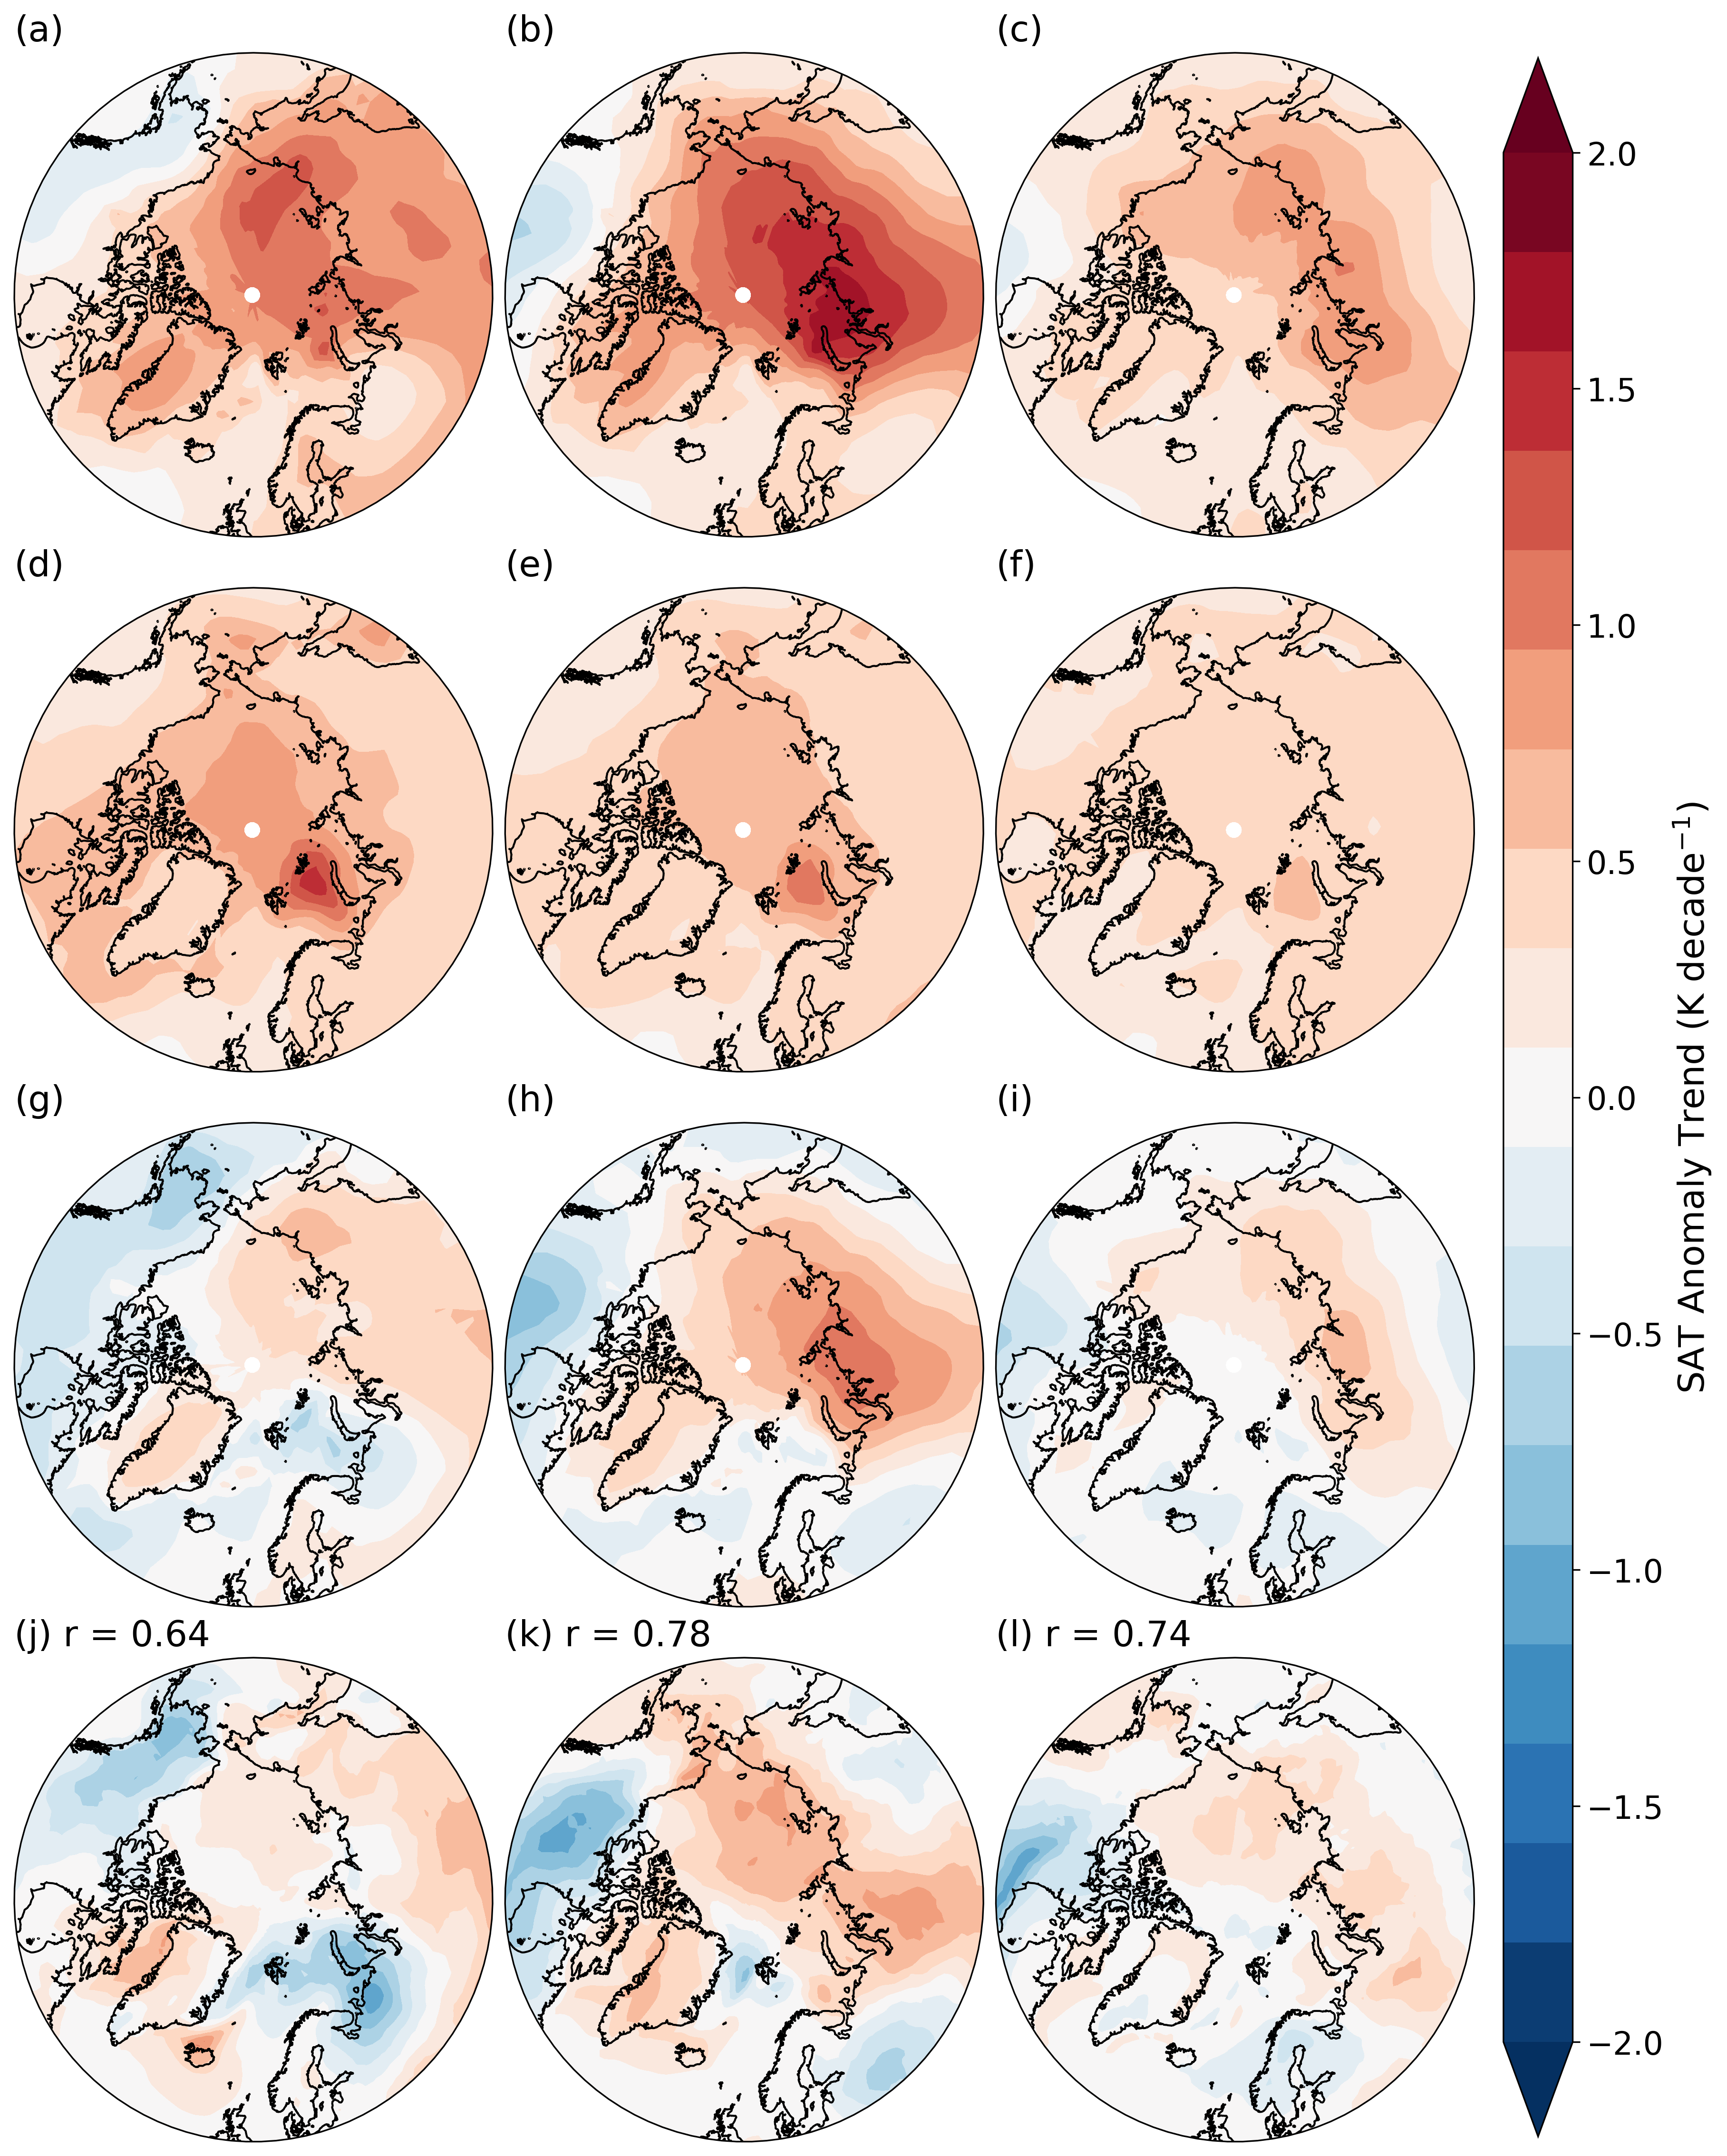

In [140]:
# 3x4 subplots with shared colorbar
# Top row: Observations, 2nd row: MMM, 3rd row: Obs-MMM, bottom row: Nudged
fig, axes = plt.subplots(
    4, 3,
    figsize=(12, 15),
    subplot_kw={'projection': ccrs.NorthPolarStereo()},
    dpi=300,
    constrained_layout=True
)

labels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)", "(g)", "(h)", "(i)", "(j)", "(k)", "(l)"]

# Loop through each subplot
for i in range(3):
    for j in range(4):
        ax = axes[j, i]
        ax.set_extent([-180, 180, 54, 90], crs=ccrs.PlateCarree())

        # Select data based on row
        if j == 0:
            sat_map = obs_sat[i]
            lats, lons = lat, lon
        elif j == 1:
            sat_map = mod_sat[i]
            lats, lons = lat, lon
        elif j == 2:
            sat_map = obs_sat[i] - mod_sat[i]
            lats, lons = lat, lon
        else:
            sat_map = nudged_sat[i]
            lats, lons = nudged_trends.lat.values, nudged_trends.lon.values

        # Filled SAT contours
        sat_map_cyclic, lon_cyclic = add_cyclic_point(sat_map, coord=lons)

        im = ax.contourf(
            lon_cyclic, lats, sat_map_cyclic,
            cmap="RdBu_r",
            levels=np.linspace(-2, 2, 20),
            extend='both',
            transform=ccrs.PlateCarree()
        )

        # Add correlation between nudged and the difference between observed and MMM in the nudged title
        if j == 3:
            deg = 60
            diff = obs_sat[i][lat >= deg] - mod_sat[i][lat >= deg]
            corr = np.corrcoef(nudged_sat_rg[i][lat >= deg].flatten(), diff.flatten())[0, 1]
            ax.set_title(f"{labels[j * 3 + i]} r = {corr:.2f}", fontsize=18, loc='left')
        else:
            ax.set_title(labels[j * 3 + i], fontsize=18, loc='left')

        ax.coastlines()
        ax.set_boundary(circle_path, transform=ax.transAxes)

# Shared vertical colorbar at right
cbar = fig.colorbar(
    im,
    ax=axes.ravel(),
    orientation='vertical',
    ticks=np.linspace(-2, 2, 9),
    shrink=0.995,
    aspect=30,
    pad=0.02
)

cbar.ax.tick_params(labelsize=16)
cbar.set_label("SAT Anomaly Trend (K decade$^{-1}$)", fontsize=18)
plt.savefig('../figures/Figure2.png', dpi=300, bbox_inches='tight')
plt.show()

### Table 1 - Internal values and forced AA

In [148]:
# Spread of ensemble means
a = spatial_average(np.array(sim_sat)[:, :, 64:], lat[64:], len(lon))
g = spatial_average(np.array(sim_sat), lat, len(lon))
aa = a / g

for i in range(3):
    # print(np.round(np.mean(a[:, i]), 3))
    # print(np.round(2*np.std(a[:, i]), 3))
    # print(np.round(np.mean(g[:, i]), 3))
    # print(np.round(2*np.std(g[:, i]), 3))
    print(np.round(2*np.std(aa[:, i]), 1))

1.5
1.2
0.6


In [150]:
months = ["March", "April", "May"]

lats = nudged_lat
lons = nudged_lon

nudged_monthly_arctic_trends = []
obs_monthly_arctic_trends = []

ERA5 = [0.633, 0.888, 0.411]

for i in range(3):
    print('----------', months[i], '----------')
    
    Observed = spatial_average(obs_sat[i, 64:], lat[64:], len(lon))
    obs_monthly_arctic_trends.append(Observed)
    print(f"Observations:  {Observed:.3f}           K/dec")

    Arctic = spatial_average(nudged_sat[i][170:], lats[170:], len(lons)) * (Observed / ERA5[i])
    nudged_monthly_arctic_trends.append(Arctic)
    Arctic_spread = np.std(spatial_average(nudged_sat_ens[:, i, 170:], lats[170:], len(lons))) * (Observed / ERA5[i])
    print(f"Nudged Arctic: {Arctic:.3f} +/- {2*Arctic_spread:.3f} K/dec\n")

    Global = spatial_average(nudged_sat[i], lats, len(lon))
    Global_spread = np.std(spatial_average(nudged_sat_ens[:, i], lats, len(lons)))
    # print(f"Nudged Global: {Global:.3f} +/- {2*Global_spread:.3f} K/dec\n")

print(f"Arctic Nudged Spring Mean:   {spatial_average(np.mean(nudged_sat, axis=0)[170:], lats[170:], len(lons)):.3f} K/dec")
print(f"Arctic Observed Spring Mean: {spatial_average(np.mean(obs_sat, axis=0)[64:], lat[64:], len(lon)):.3f} K/dec")

---------- March ----------
Observations:  0.797           K/dec
Nudged Arctic: 0.004 +/- 0.150 K/dec

---------- April ----------
Observations:  1.004           K/dec
Nudged Arctic: 0.391 +/- 0.016 K/dec

---------- May ----------
Observations:  0.558           K/dec
Nudged Arctic: 0.168 +/- 0.137 K/dec

Arctic Nudged Spring Mean:   0.157 K/dec
Arctic Observed Spring Mean: 0.786 K/dec


### Figure 3 - Regional SAT-SLP correlations

In [154]:
months = ["March", "April", "May"]
print("-" * 60)

for i, month in enumerate(months):
    obs_slp_val = spatial_average(
        obs_slp[i, 60:68, 14:35],
        lat[60:68],
        len(lon[14:35])
    )

    mod_slp_val = spatial_average(
        mod_slp[i, 60:68, 14:35],
        lat[60:68],
        len(lon[14:35])
    ) / 100

    nudged_slp_val = spatial_average(
        nudged_slp_rg[i, 60:68, 14:35],
        lat[60:68],
        len(lon[14:35])
    )

    obs_sat_val = spatial_average(
        obs_sat[i, 62:68, 24:63],
        lat[62:68],
        len(lon[24:63])
    )

    mod_sat_val = spatial_average(
        mod_sat[i, 62:68, 24:63],
        lat[62:68],
        len(lon[24:63])
    )

    nudged_sat_val = spatial_average(
        nudged_sat_rg[i, 62:68, 24:63],
        lat[62:68],
        len(lon[24:63])
    )

    print(f"{month}")
    print(f"  SLP  | Obs: {obs_slp_val:6.2f}  | MMM: {mod_slp_val:6.2f} | Nudged: {nudged_slp_val:6.2f}")
    print(f"  SAT  | Obs: {obs_sat_val:6.3f}  | MMM: {mod_sat_val:6.3f} | Nudged: {nudged_sat_val:6.3f}")
    print("-" * 60)

------------------------------------------------------------
March
  SLP  | Obs:  -2.55  | MMM:  -0.18 | Nudged:  -1.79
  SAT  | Obs:  0.934  | MMM:  0.614 | Nudged:  0.017
------------------------------------------------------------
April
  SLP  | Obs:  -1.00  | MMM:  -0.20 | Nudged:  -0.77
  SAT  | Obs:  1.384  | MMM:  0.537 | Nudged:  0.522
------------------------------------------------------------
May
  SLP  | Obs:  -0.33  | MMM:  -0.04 | Nudged:  -0.19
  SAT  | Obs:  0.784  | MMM:  0.368 | Nudged:  0.257
------------------------------------------------------------


In [152]:
# Get density contours
Z_all = []

for month_idx in range(3):
    x = slp_internal[:, month_idx, 60:68, 14:35] / 100
    y = sat_internal[:, month_idx, 62:68, 24:63]

    x_avg = spatial_average(x, lat[60:68], len(lon[14:35]))
    y_avg = spatial_average(y, lat[62:68], len(lon[24:63]))

    xy = np.vstack([x_avg, y_avg])
    kde = gaussian_kde(xy)

    xi = np.linspace(-3.5, 3.5, 150)
    yi = np.linspace(-1.5, 1.5, 150)
    Xg, Yg = np.meshgrid(xi, yi)
    Z = kde(np.vstack([Xg.ravel(), Yg.ravel()])).reshape(Xg.shape)
    Z = Z / Z.max()

    Z_all.append(Z)

levels = [0.1, 0.25, 0.5, 0.7, 0.9]

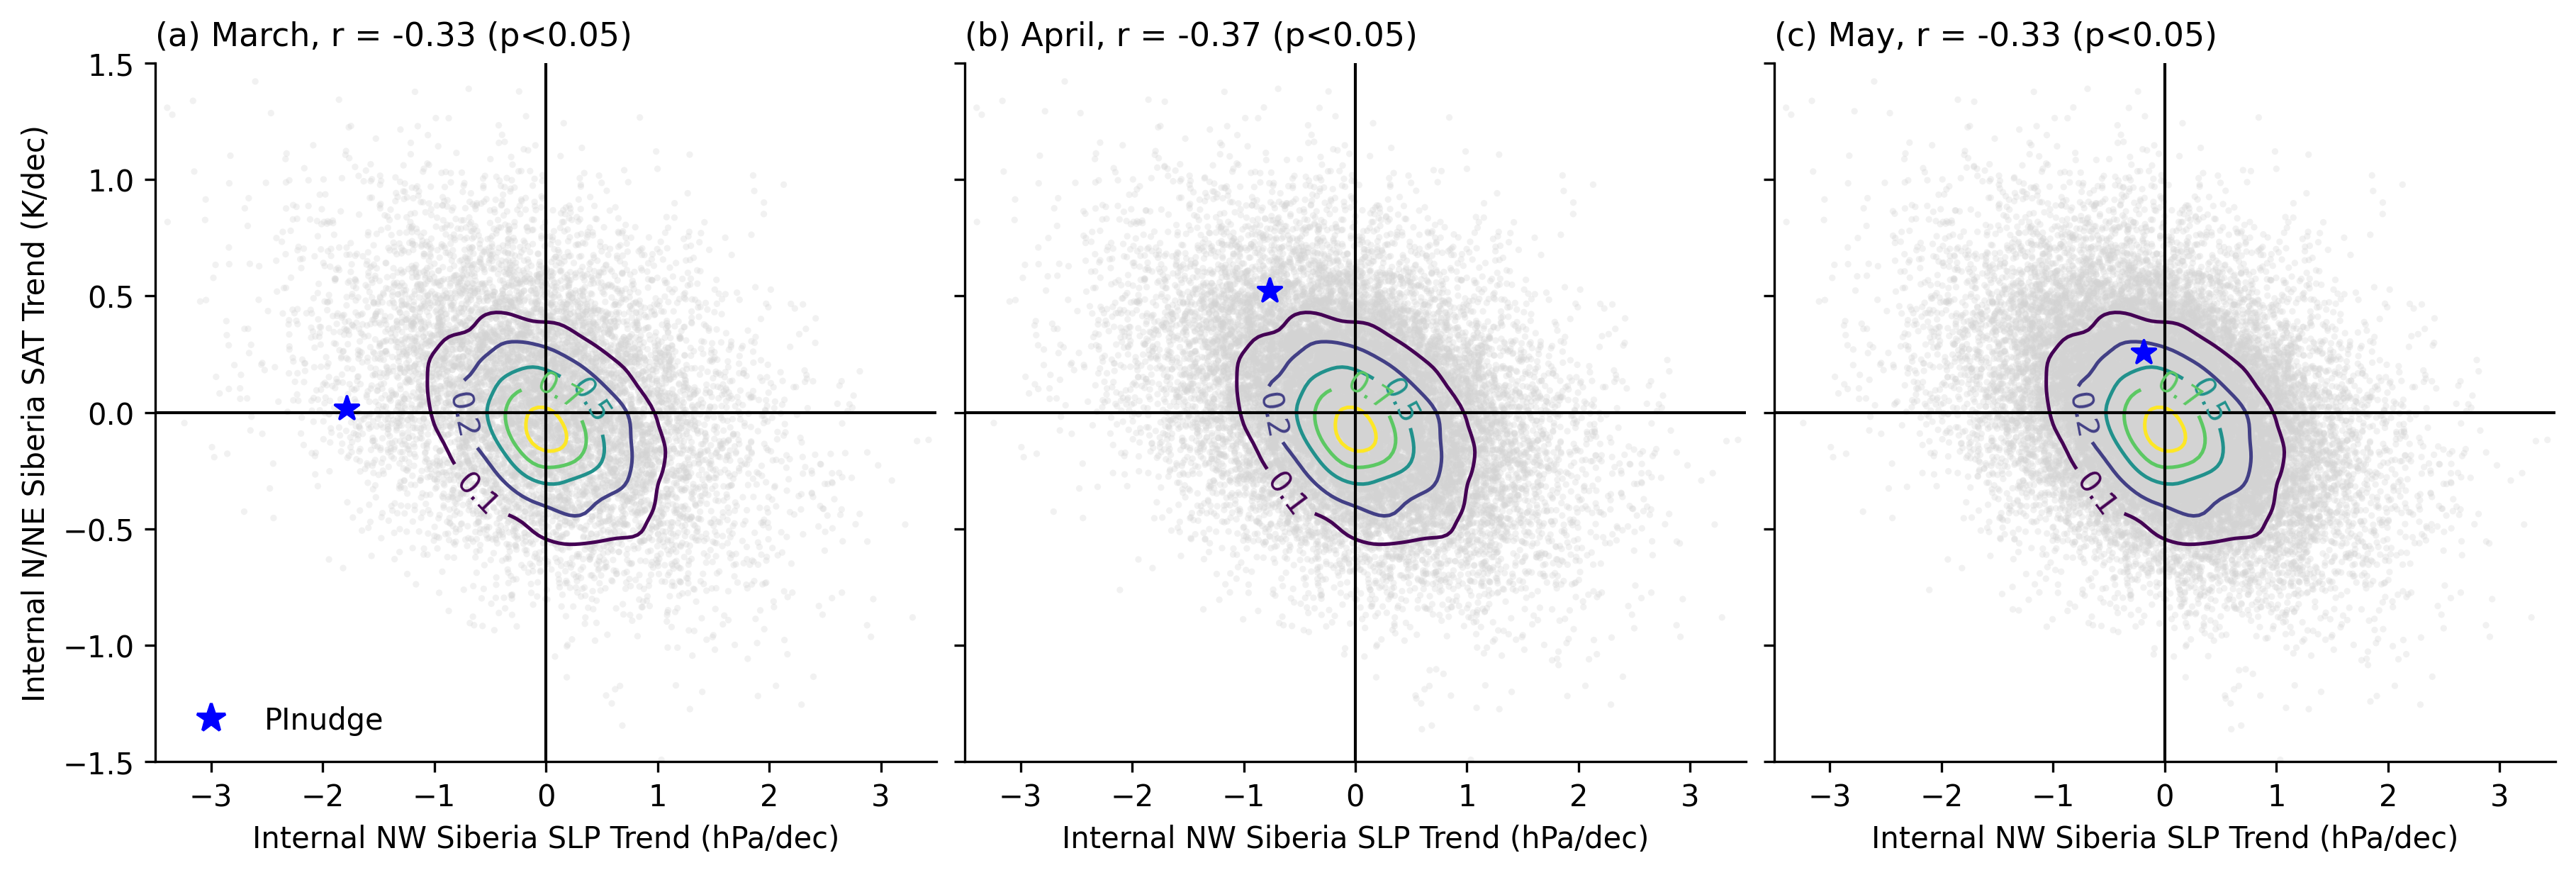

In [155]:
# 1x3 subplots of density
labels = ["(a) March", "(b) April", "(c) May"]

fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 4),
    dpi=300,
    constrained_layout=True,
    sharey=True
)

x_avgs, y_avgs = [], []

for month_idx in range(3):
    ax = axes[month_idx]

    # Spatial average of selected regions
    x = slp_internal[:, month_idx, 60:68, 14:35] / 100  # hPa
    y = sat_internal[:, month_idx, 62:68, 24:63]

    x_avg = spatial_average(x, lat[60:68], len(lon[14:35]))
    y_avg = spatial_average(y, lat[62:68], len(lon[24:63]))

    x_avgs.append(x_avg)
    y_avgs.append(y_avg)

    # Correlation
    corr_coef, p_value = stats.pearsonr(x_avg, y_avg)
    significance = " (p<0.05)" if p_value < 0.05 else ""

    ax.scatter(x_avgs, y_avgs, color='lightgrey', alpha=0.3, s=5, edgecolors='none')

    # Density contour
    cs = ax.contour(
        Xg, Yg, Z,
        levels=levels,
        cmap="viridis",
        linewidths=1.2
    )
    ax.clabel(cs, fmt="%.1f", fontsize=10)

    ax.axhline(0, color="k", lw=1)
    ax.axvline(0, color="k", lw=1)
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-1.5, 1.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Observed value
    '''
    observed = {
        0: (-2.368718114595667, 0.32643064679727984),  # March
        1: (-0.7940412441449607, 0.8526703529858402),  # April
        2: (-0.29191823970081302, 0.4206435706147982)  # May
    }

    ax.scatter(
        *observed[month_idx],
        color="blue", marker="*", s=70, zorder=5
    )
    '''

    nudged = {
        0: (-1.7854258732416266, 0.016964273004145818),  # March
        1: (-0.7681126518543514, 0.5215546178562999),    # April
        2: (-0.18799142781732106, 0.2571610729105704)    # May
    }

    ax.scatter(
        *nudged[month_idx],
        color="blue", marker="*", s=70, zorder=5
    )

    ax.set_title(
        f"{labels[month_idx]}, r = {corr_coef:.2f}{significance}",
        fontsize=11, loc='left'
    )

    if month_idx == 0:
        ax.set_ylabel("Internal N/NE Siberia SAT Trend (K/dec)")
    ax.set_xlabel("Internal NW Siberia SLP Trend (hPa/dec)")

    if month_idx == 0:
        handles = []
        handles.append(Line2D([0], [0], marker="*", color="blue", linestyle="None", markersize=10, label="PInudge"))
        legend = ax.legend(handles=handles, loc="lower left", frameon=False)

plt.savefig('../figures/FigureS4.png', dpi=300, bbox_inches='tight')
plt.show()

In [104]:
# Observed values (x = SLP, y = SAT)
observed = [
    (-236.8718114595667, 0.32643064679727984),
    (-79.40412441449607, 0.8526703529858402),
    (-29.191823970081302, 0.4206435706147982),
]

months = ["March", "April", "May"]


def report_stats(x_avg, y_avg, obs_x, obs_y):
    # Means and standard deviations
    x_mean, x_std = np.mean(x_avg), np.std(x_avg, ddof=1)
    y_mean, y_std = np.mean(y_avg), np.std(y_avg, ddof=1)

    # Sigma distances
    x_sigma = (obs_x - x_mean) / x_std
    y_sigma = (obs_y - y_mean) / y_std
    hyp_sigma = np.sqrt(x_sigma**2 + y_sigma**2)

    # Percentages
    slp_pct = np.mean(x_avg <= obs_x) * 100
    sat_pct = np.mean(y_avg >= obs_y) * 100
    tot_pct = np.mean((x_avg <= (2/3)*obs_x) & (y_avg >= (2/3)*obs_y)) * 100

    return x_sigma, y_sigma, hyp_sigma, slp_pct, sat_pct, tot_pct


for i, (obs_x, obs_y) in enumerate(observed):
    xσ, yσ, hσ, slp_pct, sat_pct, tot_pct = report_stats(x_avgs[i], y_avgs[i], obs_x, obs_y)

    print(f"\n--------- {months[i]} ---------")
    print(f"Observed SLP:       {xσ:.1f}σ")
    print(f"Observed SAT:       {yσ:.1f}σ")
    print(f"Distance from mean: {hσ:.1f}σ")
    print(f"SLP percentile:     {slp_pct:.0f}%")
    print(f"SAT percentile:     {sat_pct:.0f}%")
    print(f"Joint percentile:   {tot_pct:.0f}%")

print("\n")


--------- March ---------
Observed SLP:       -2.6σ
Observed SAT:       0.7σ
Distance from mean: 2.7σ
SLP percentile:     1%
SAT percentile:     23%
Joint percentile:   3%

--------- April ---------
Observed SLP:       -1.0σ
Observed SAT:       2.6σ
Distance from mean: 2.8σ
SLP percentile:     14%
SAT percentile:     1%
Joint percentile:   2%

--------- May ---------
Observed SLP:       -0.6σ
Observed SAT:       2.0σ
Distance from mean: 2.0σ
SLP percentile:     27%
SAT percentile:     2%
Joint percentile:   4%


